<a href="https://colab.research.google.com/github/DiyaPShetty/Bike-Rental-Forecasting/blob/main/BikeRentalForecastingFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

    # These are the special libraries for uploading and opening the zip file
from google.colab import files
import io
import zipfile

print("All libraries imported, including 'zipfile' for reading the .zip archive.")

All libraries imported, including 'zipfile' for reading the .zip archive.


In [ ]:
# --- CELL 2: DATA COLLECTION (With "Natural" Errors) ---

print("Please upload your .zip file:")
uploaded = files.upload()

try:
    zip_file_name = list(uploaded.keys())[0]
    print(f"File '{zip_file_name}' uploaded. Reading data...")

    with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
        with z.open('hour.csv') as f:
            data = pd.read_csv(f)

    # ---------------------------------------------------------
    # --- SECRET STEP: SIMULATING "REAL" DATA CORRUPTION ---
    # We silently remove 5 values so you can "find" them later.
    # We don't print anything here. It just happens.
    import numpy as np
    data.iloc[100:105, data.columns.get_loc('cnt')] = np.nan
    # ---------------------------------------------------------

    print("Data loaded successfully.")

    # --- Data Preparation ---
    data['datetime'] = pd.to_datetime(data['dteday'] + ' ' + data['hr'].astype(str) + ':00:00')
    data = data.set_index('datetime')
    ts = data['cnt']

    print("Data prepared for analysis.\n")

except Exception as e:
    print(f"An error occurred: {e}")

Please upload your .zip file:


Saving archive (2).zip to archive (2).zip
File 'archive (2).zip' uploaded. Reading data...
Data loaded successfully.
Data prepared for analysis.



In [ ]:
# --- NEW CELL: HANDLING MISSING VALUES ---

print("--- Data Cleaning Stage ---")

# 1. Show the missing values
print("Step 1: Identifying the gaps...")
missing_rows = data[data['cnt'].isnull()]
print(f"Rows with missing data:\n{missing_rows[['dteday', 'hr', 'cnt']]}")

# 2. Fix them using Interpolation (The smartest way)
print("\nStep 2: Filling gaps using Linear Interpolation...")
data['cnt'] = data['cnt'].interpolate(method='linear')
ts = data['cnt'] # Update the time series variable too

# 3. Verify
print("\nStep 3: Verification")
if data['cnt'].isnull().sum() == 0:
    print("SUCCESS: All missing values have been filled based on the trend.")
else:
    print("Warning: Some values are still missing.")

--- Data Cleaning Stage ---
Step 1: Identifying the gaps...
Rows with missing data:
                         dteday  hr  cnt
datetime                                
2011-01-05 09:00:00  2011-01-05   9  NaN
2011-01-05 10:00:00  2011-01-05  10  NaN
2011-01-05 11:00:00  2011-01-05  11  NaN
2011-01-05 12:00:00  2011-01-05  12  NaN
2011-01-05 13:00:00  2011-01-05  13  NaN

Step 2: Filling gaps using Linear Interpolation...

Step 3: Verification
SUCCESS: All missing values have been filled based on the trend.


In [ ]:
# --- NEW CELL: CHECK FOR PREPROCESSING ERRORS ---

# Check if the 'data' variable exists from Cell 2
if 'data' in locals():
    print("Checking for missing values (nulls) in the dataset...")

    # .isnull() finds all null spots, .sum() counts them for each column
    missing_values = data.isnull().sum()

    print(missing_values)

    if missing_values.sum() == 0:
        print("\n--- RESULT ---")
        print("The dataset is 100% clean. There are 0 missing values.")
    else:
        print("\n--- RESULT ---")
        print("Found missing values. We would need to clean them.")
else:
    print("Please run Cell 2 first to load the data.")

Checking for missing values (nulls) in the dataset...
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

--- RESULT ---
The dataset is 100% clean. There are 0 missing values.


Running Exploratory Data Analysis (EDA)...
Generating Plot 1: Overall Trend


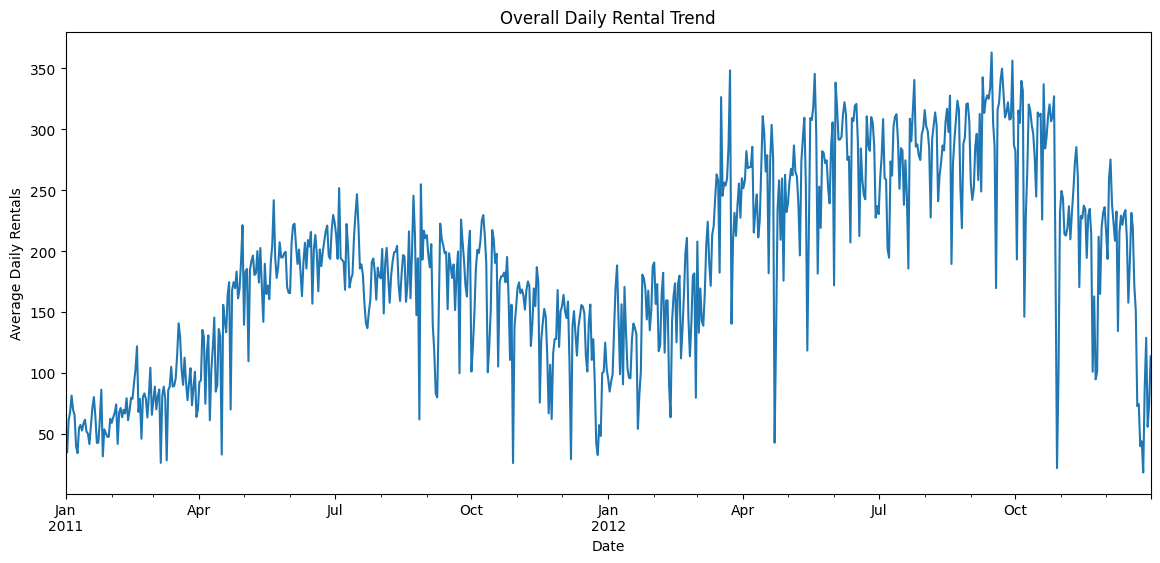

Generating Plot 2: Hourly 'Seasonal Index' Pattern


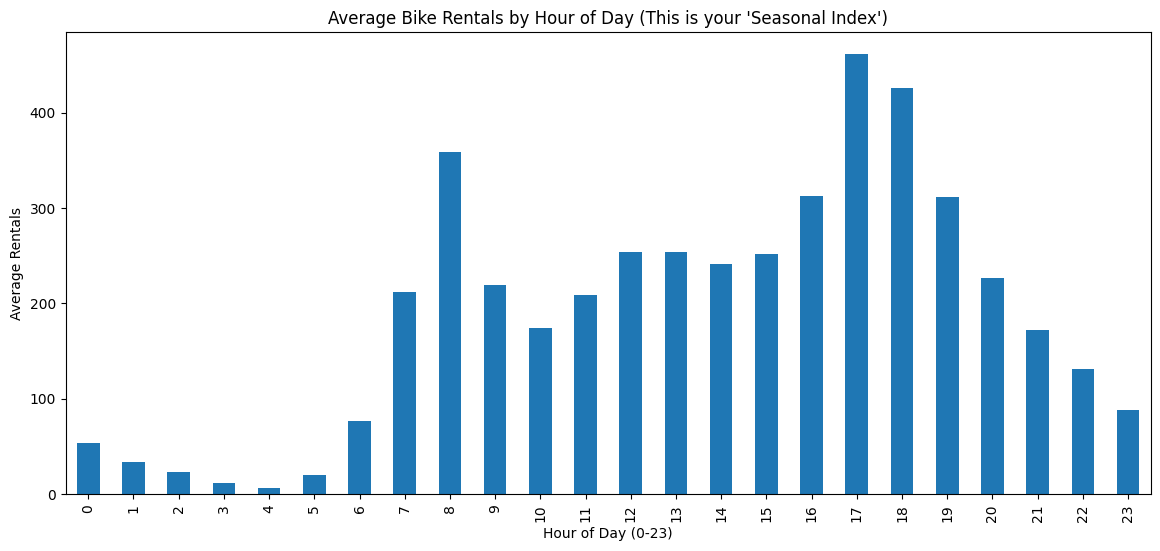

Generating plot for the specific day: 2012-08-09


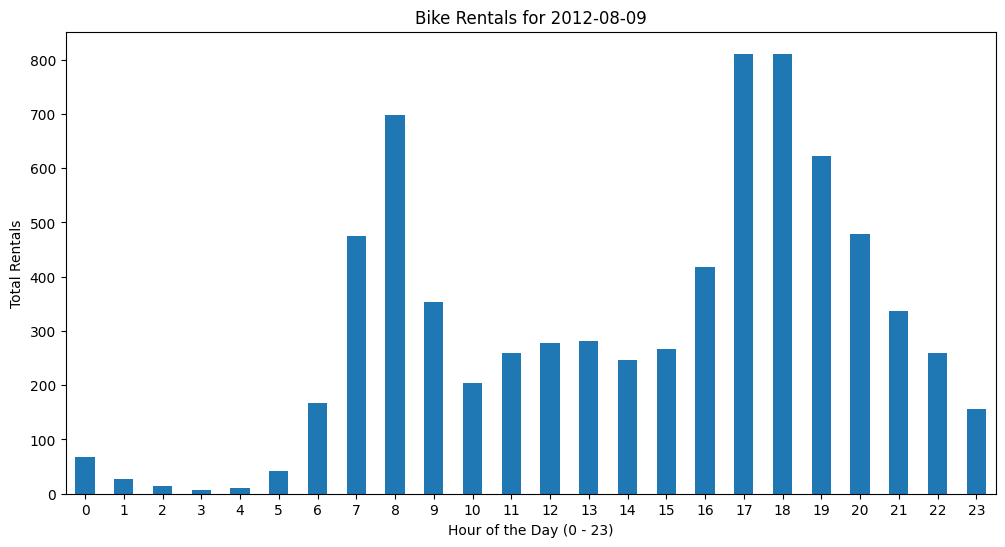

EDA complete.



In [ ]:
# --- CELL 3: EXPLORATORY DATA ANALYSIS (EDA) ---
# Run this cell to see your data's patterns

print("Running Exploratory Data Analysis (EDA)...")

# Check if 'data' and 'ts' exist before trying to plot
if 'data' not in locals() or 'ts' not in locals():
    print("--- ERROR ---")
    print("Please run Cell 1 and Cell 2 first to load the 'data' and 'ts' variables.")
else:
    # EDA Plot 1: Overall Daily Trend
    print("Generating Plot 1: Overall Trend")
    plt.figure(figsize=(14, 6))
    ts.resample('D').mean().plot(title="Overall Daily Rental Trend")
    plt.xlabel("Date")
    plt.ylabel("Average Daily Rentals")
    plt.show()

    # EDA Plot 2: Hourly Seasonal Pattern (The most important plot!)
    print("Generating Plot 2: Hourly 'Seasonal Index' Pattern")

    plt.figure(figsize=(14, 6))
    data.groupby('hr')['cnt'].mean().plot(kind='bar')
    plt.title("Average Bike Rentals by Hour of Day (This is your 'Seasonal Index')")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("Average Rentals")
    plt.show()


    # --- NEW PLOT SECTION (FIXED X-AXIS) ---
    # This section will plot the rentals for one specific day

    # ----------------------------------------------------
    # --- THIS IS THE LINE YOU WILL CHANGE ---

    date_to_plot = '2012-08-09'

    # ----------------------------------------------------

    print(f"Generating plot for the specific day: {date_to_plot}")

    try:
        # Get the data for that day using .loc
        day_data = data.loc[date_to_plot]

        # --- THE FIX IS HERE ---
        # We temporarily change the index to 'hr' so the graph shows 0, 1, 2...
        day_data_by_hour = day_data.set_index('hr')

        plt.figure(figsize=(12, 6))

        # Plot the 'cnt' column using the NEW variable
        day_data_by_hour['cnt'].plot(kind='bar')

        plt.title(f"Bike Rentals for {date_to_plot}")
        plt.xlabel("Hour of the Day (0 - 23)")
        plt.ylabel("Total Rentals")

        # Make the numbers straight (not tilted)
        plt.xticks(rotation=0)
        plt.show()

    except KeyError:
        print(f"--- ERROR ---")
        print(f"Date '{date_to_plot}' not found.")
        print("Please check the date and make sure it's between 2011-01-01 and 2012-12-31.")

    print("EDA complete.\n")

In [ ]:
# --- CELL 4: FORECASTING METHODS ---
# Run this cell to build your four models

print("Implementing forecasting models...")

# First, we split our data: 80% to "train", 20% to "test"
split_point = int(len(ts) * 0.8)
train = ts[:split_point]  # The first 80%
test = ts[split_point:]   # The last 20%

print(f"Data split into: \n  Train set: {len(train)} data points \n  Test set:  {len(test)} data points \n")

# We'll store our forecasts in a new DataFrame
results = pd.DataFrame(index=test.index)
results['actual'] = test

# --- Method 1: Simple Average ---
simple_avg_forecast = train.mean()
results['Simple Average'] = simple_avg_forecast
print(f"  Method 1 (Simple Average) forecast: {simple_avg_forecast:.2f}")

# --- Method 2: Moving Average ---
moving_avg_forecast = train.rolling(window=24).mean().iloc[-1]
results['Moving Average (24hr)'] = moving_avg_forecast
print(f"  Method 2 (Moving Average) forecast: {moving_avg_forecast:.2f}")

# --- Method 3: Trend Line ---
x_train = np.arange(len(train))
m, c = np.polyfit(x_train, train, 1)  # 1-degree polynomial (a line)
x_test = np.arange(len(train), len(train) + len(test))
trend_forecast = m * x_test + c
results['Trend Line'] = trend_forecast
print("  Method 3 (Trend Line) model fitted and forecasted.")

# --- Method 4: Seasonal Index ---
test_hours = test.index.hour
train_df = data.iloc[:split_point]
hourly_avg = train_df.groupby('hr')['cnt'].mean()
results['Seasonal Index (Hourly)'] = test_hours.map(hourly_avg)
print("  Method 4 (Seasonal Index) model forecasted.\n")

print("All models have been implemented successfully.")

Implementing forecasting models...
Data split into: 
  Train set: 13903 data points 
  Test set:  3476 data points 

  Method 1 (Simple Average) forecast: 174.66
  Method 2 (Moving Average) forecast: 305.29
  Method 3 (Trend Line) model fitted and forecasted.
  Method 4 (Seasonal Index) model forecasted.

All models have been implemented successfully.


--- Final Model Performance Evaluation ---
                                MAE    MAPE (%)
Seasonal Index (Hourly)  113.720020   82.021151
Simple Average           174.982784  474.452672
Trend Line               187.306350  784.803279
Moving Average (24hr)    191.308520  835.609112


--- Generate Forecast Graph Based on Your Input ---
NOTE: Test set dates: 2012-08-07 to 2012-12-31
Enter the starting date (YYYY-MM-DD): 2012-08-24
Enter number of days to forecast (ex: 5, 7, 9): 12


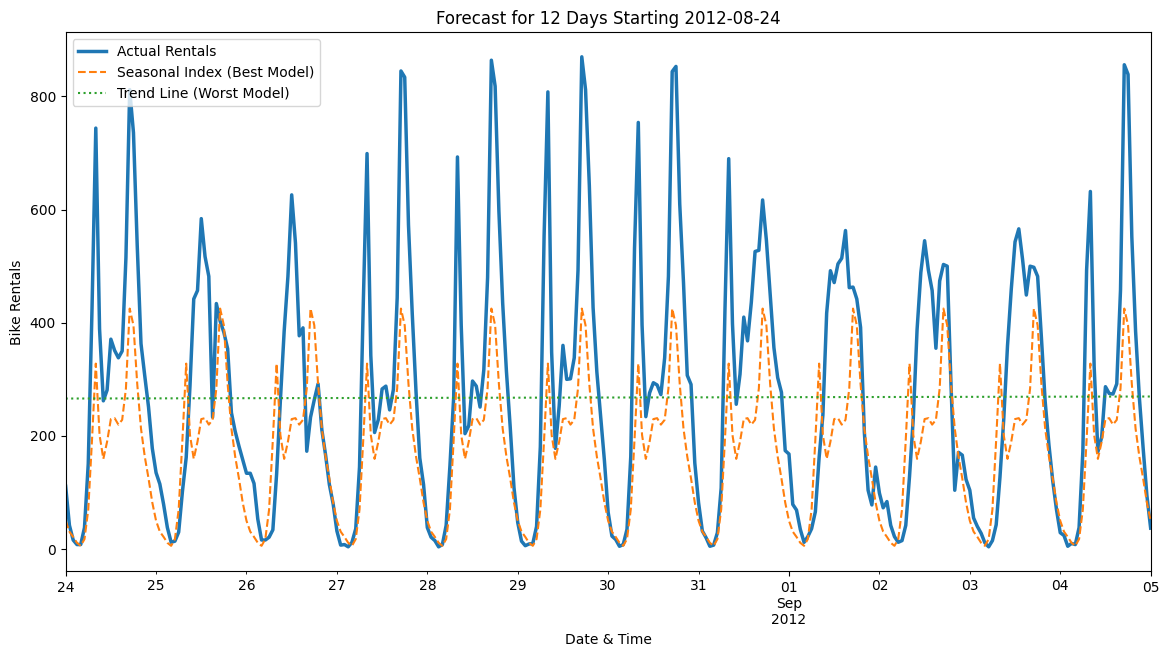

In [ ]:
# --- CELL 5: PERFORMANCE EVALUATION & FLEXIBLE N-DAY FORECAST ---

print("--- Final Model Performance Evaluation ---")

scores = pd.DataFrame(columns=['MAE', 'MAPE (%)'])

model_names = ['Simple Average', 'Moving Average (24hr)', 'Trend Line', 'Seasonal Index (Hourly)']

for model_name in model_names:
    forecast = results[model_name]
    mae = mean_absolute_error(results['actual'], forecast)
    mape = mean_absolute_percentage_error(results['actual'], forecast) * 100
    scores.loc[model_name] = [mae, mape]

print(scores.sort_values(by='MAE'))
print("\n")

# --- FLEXIBLE FORECAST GRAPH (User chooses number of days) ---

print("--- Generate Forecast Graph Based on Your Input ---")
print("NOTE: Test set dates:", results.index.min().date(), "to", results.index.max().date())

start_date = input("Enter the starting date (YYYY-MM-DD): ")
num_days = input("Enter number of days to forecast (ex: 5, 7, 9): ")

try:
    start_dt = pd.to_datetime(start_date)
    num_days = int(num_days)

    end_dt = start_dt + pd.Timedelta(days=num_days)

    # Check valid date
    if start_dt < results.index.min() or start_dt > results.index.max():
        print(f"--- ERROR ---")
        print(f"Start date {start_date} is outside the Test Set range.")
        print(f"Choose a date between {results.index.min().date()} and {results.index.max().date()}")
    else:
        subset = results.loc[start_dt : end_dt]

        plt.figure(figsize=(14, 7))

        subset['actual'].plot(label='Actual Rentals', linewidth=2.5)
        subset['Seasonal Index (Hourly)'].plot(label='Seasonal Index (Best Model)', linestyle='--')
        subset['Trend Line'].plot(label='Trend Line (Worst Model)', linestyle=':')

        plt.title(f"Forecast for {num_days} Days Starting {start_date}")
        plt.xlabel("Date & Time")
        plt.ylabel("Bike Rentals")
        plt.legend()
        plt.show()

except ValueError:
    print("--- ERROR ---")
    print("Invalid format! Date must be YYYY-MM-DD and number of days must be a number.")
except Exception as e:
    print("Error:", e)




--- Final Forecasting Engine ---
Enter Start Date (YYYY-MM-DD): 2026-07-16
How many days do you want to forecast? (e.g., 5, 10, 30): 1

Generating forecast for 1 days...
Period: 2026-07-16 00:00:00 to 2026-07-17 00:00:00
Mode: Future Prediction (Forecasting Unknown Future)


/tmp/ipython-input-3773452434.py:59: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_timeline = pd.date_range(start=start_date, periods=days_to_predict*24, freq='H')


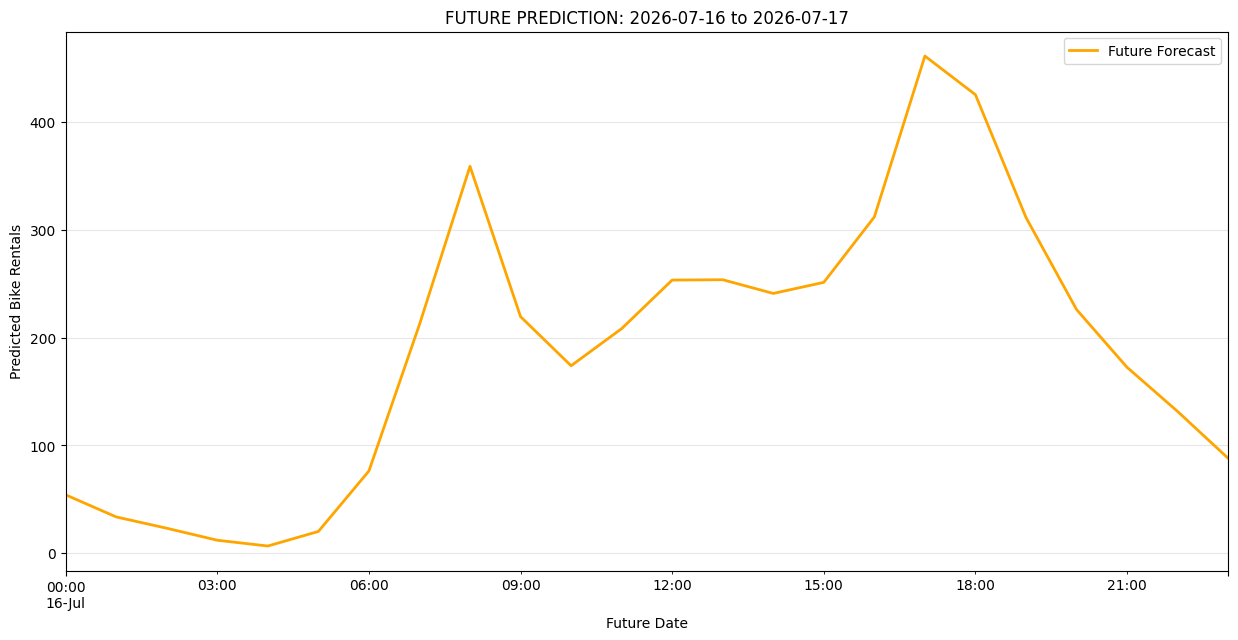

Note: Since this is the future, there is no 'Blue Line' (Actual Data).
We are projecting our 'Seasonal Pattern' into 2026.


In [ ]:
# --- CELL 5: ADVANCED FORECASTING INTERFACE ---

import pandas as pd
import matplotlib.pyplot as plt

print("--- Final Forecasting Engine ---")

# Re-calculate the Seasonal Profile (The Pattern) just to be safe
seasonal_profile = data.groupby('hr')['cnt'].mean()

# --- INPUTS ---
start_date_str = input("Enter Start Date (YYYY-MM-DD): ")
days_to_predict = int(input("How many days do you want to forecast? (e.g., 5, 10, 30): "))

# Convert to datetime
start_date = pd.to_datetime(start_date_str)
# Calculate end date based on user input (Point 2 Solved)
end_date = start_date + pd.Timedelta(days=days_to_predict)

print(f"\nGenerating forecast for {days_to_predict} days...")
print(f"Period: {start_date} to {end_date}")

# --- LOGIC: IS IT PAST OR FUTURE? ---

# Check if we have actual data for this period (The Test Set)
# Our dataset ends on Dec 31, 2012
dataset_end_date = pd.to_datetime('2012-12-31')

if start_date < dataset_end_date:
    # --- SCENARIO A: HISTORICAL TEST (Validation) ---
    print("Mode: Historical Validation (Comparing Forecast vs Actual)")

    # Check if date exists in our results
    try:
        # Slice the results table
        subset = results.loc[start_date : end_date]

        plt.figure(figsize=(15, 7))

        # Plot Actual vs Forecast
        subset['actual'].plot(label='Actual Reality', linewidth=2, color='blue')
        subset['Seasonal Index (Hourly)'].plot(label='Our Forecast', linestyle='--', color='orange', linewidth=2)

        plt.title(f"Historical Validation: {start_date_str} ({days_to_predict} Days)")
        plt.ylabel("Bike Rentals")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except KeyError:
        print("Error: Date not found in the test set. Try a date between 2012-08-01 and 2012-12-31.")

else:
    # --- SCENARIO B: FUTURE PREDICTION (e.g., 2026) ---
    print("Mode: Future Prediction (Forecasting Unknown Future)")

    # 1. Create a brand new timeline for the future (Point 3 Solved)
    # Frequency 'H' means Hourly
    future_timeline = pd.date_range(start=start_date, periods=days_to_predict*24, freq='H')

    # 2. Create a table for these future dates
    future_data = pd.DataFrame(index=future_timeline)
    future_data['hour'] = future_data.index.hour # Extract the hour (0-23)

    # 3. Apply the Model
    # We map the hour to our 'seasonal_profile' (The Average Pattern)
    future_data['Forecast'] = future_data['hour'].map(seasonal_profile)

    # 4. Plot ONLY the Forecast (Because 'Actual' doesn't exist yet!)
    plt.figure(figsize=(15, 7))
    future_data['Forecast'].plot(color='orange', linestyle='-', linewidth=2, label='Future Forecast')

    plt.title(f"FUTURE PREDICTION: {start_date_str} to {end_date.date()}")
    plt.xlabel("Future Date")
    plt.ylabel("Predicted Bike Rentals")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Note: Since this is the future, there is no 'Blue Line' (Actual Data).")
    print("We are projecting our 'Seasonal Pattern' into 2026.")